In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("customer_support_tickets.csv")

print(df.shape)
df.head()
df.columns

(20000, 12)


Index(['Ticket_ID', 'Customer_Name', 'Customer_Email', 'Ticket_Subject',
       'Ticket_Description', 'Issue_Category', 'Priority_Level',
       'Ticket_Channel', 'Submission_Date', 'Resolution_Time_Hours',
       'Assigned_Agent', 'Satisfaction_Score'],
      dtype='object')

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Ticket_ID              20000 non-null  object
 1   Customer_Name          20000 non-null  object
 2   Customer_Email         20000 non-null  object
 3   Ticket_Subject         20000 non-null  object
 4   Ticket_Description     20000 non-null  object
 5   Issue_Category         20000 non-null  object
 6   Priority_Level         20000 non-null  object
 7   Ticket_Channel         20000 non-null  object
 8   Submission_Date        20000 non-null  object
 9   Resolution_Time_Hours  20000 non-null  int64 
 10  Assigned_Agent         20000 non-null  object
 11  Satisfaction_Score     20000 non-null  int64 
dtypes: int64(2), object(10)
memory usage: 1.8+ MB
None


In [6]:
df.describe(include='all')

,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
count,20000,20000,20000,20000,20000,20000,20000,20000,20000,20000.000000,20000,20000.000000
unique,20000,17900,19489,13943,20000,5,4,3,731,NaN,5,NaN
top,TKT-119983,William Smith,vjohnson@example.org,Refund status - Ball,"Hi Support, I lost my phone and cannot pass th...",Technical,Low,Chat,2025-05-11,NaN,Anya Sharma,NaN
freq,1,11,4,5,1,5918,7716,6693,45,NaN,4025,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.230300,NaN,3.723700
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.221884,NaN,1.286989
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.000000,NaN,3.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,4.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.000000,NaN,5.000000


In [9]:
duplicates = df.duplicated().sum()

print(
    f"Duplicate Rows = {duplicates}"
)

Duplicate Rows = 0


In [10]:
df["combined_text"] = (
    df["Ticket_Subject"].astype(str)
    + " "
    + df["Ticket_Description"].astype(str)
)

In [11]:
df["email_domain"] = (
    df["Customer_Email"]
    .str.split("@")
    .str[-1]
)

In [12]:
df["description_length"] = (
    df["Ticket_Description"]
    .astype(str)
    .apply(len)
)

In [13]:
df["subject_length"] = (
    df["Ticket_Subject"]
    .astype(str)
    .apply(len)
)

<Axes: xlabel='Priority_Level', ylabel='count'>

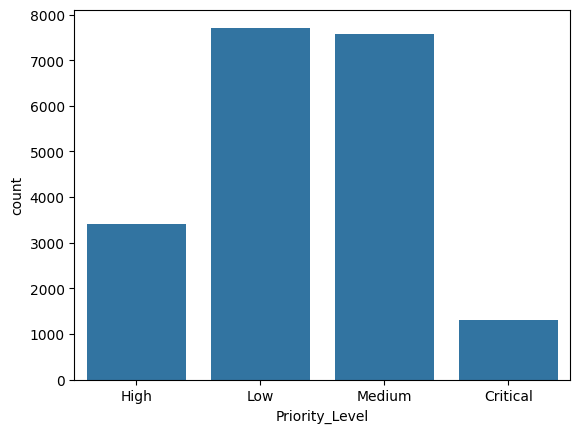

In [14]:
sns.countplot(
    x="Priority_Level",
    data=df
)

In [15]:
pd.crosstab(
    df["Issue_Category"],
    df["Priority_Level"]
)

Priority_Level,Critical,High,Low,Medium
Issue_Category,,,,
Account,0,405,2054,1622
Billing,0,550,2524,1962
Fraud,716,324,0,0
General Inquiry,0,389,1968,1568
Technical,582,1748,1170,2418


<Axes: xlabel='Priority_Level', ylabel='Issue_Category'>

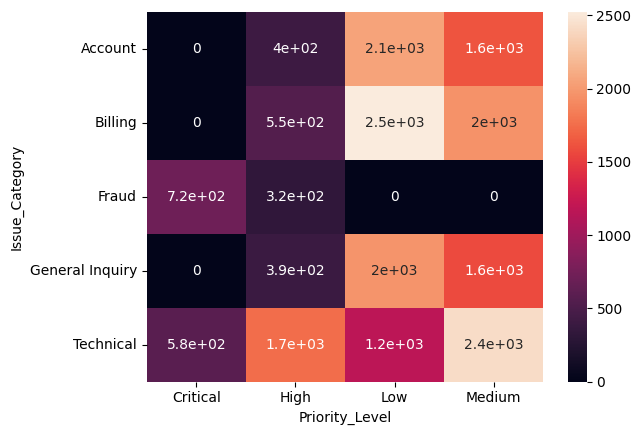

In [17]:
sns.heatmap(
    pd.crosstab(
        df["Issue_Category"],
        df["Priority_Level"]
    ),
    annot=True
)

<Axes: xlabel='Priority_Level', ylabel='Resolution_Time_Hours'>

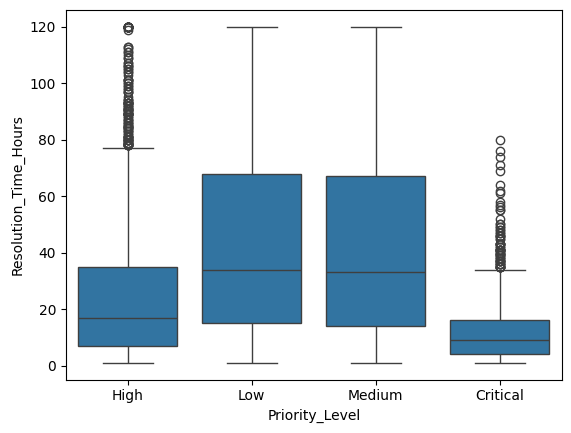

In [18]:
sns.boxplot(
    x="Priority_Level",
    y="Resolution_Time_Hours",
    data=df
)

<Axes: xlabel='Priority_Level', ylabel='Satisfaction_Score'>

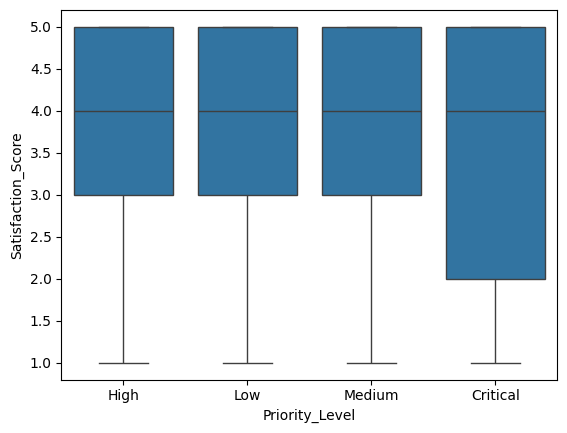

In [19]:
sns.boxplot(
    x="Priority_Level",
    y="Satisfaction_Score",
    data=df
)

In [21]:
df["combined_text"] = (
    df["Ticket_Subject"]
    .astype(str)
    +
    " "
    +
    df["Ticket_Description"]
    .astype(str)
)

In [22]:
import re

def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r'http\\S+',
        '',
        text
    )

    text = re.sub(
        r'[^a-zA-Z ]',
        '',
        text
    )

    text = re.sub(
        r'\\s+',
        ' ',
        text
    )

    return text.strip()

In [23]:
df["clean_text"] = (
    df["combined_text"]
    .apply(clean_text)
)

In [24]:
df[
    [
        "combined_text",
        "clean_text"
    ]
].head()

,combined_text,clean_text
0,"Hours of operation - Individual Hi Support, Wh...",hours of operation individual hi support wher...
1,"Data not syncing - Card Hi Support, The applic...",data not syncing card hi support the applicat...
2,"2FA issues - Question Hi Support, How do I upg...",fa issues question hi support how do i upgrad...
3,"Login failed - Let Hi Support, The dashboard i...",login failed let hi support the dashboard is ...
4,"Refund status - Attention Hi Support, I have b...",refund status attention hi support i have bee...


In [25]:
numeric_cols = [

    "Resolution_Time_Hours",

    "Satisfaction_Score",

    "subject_length",

    "description_length"
]

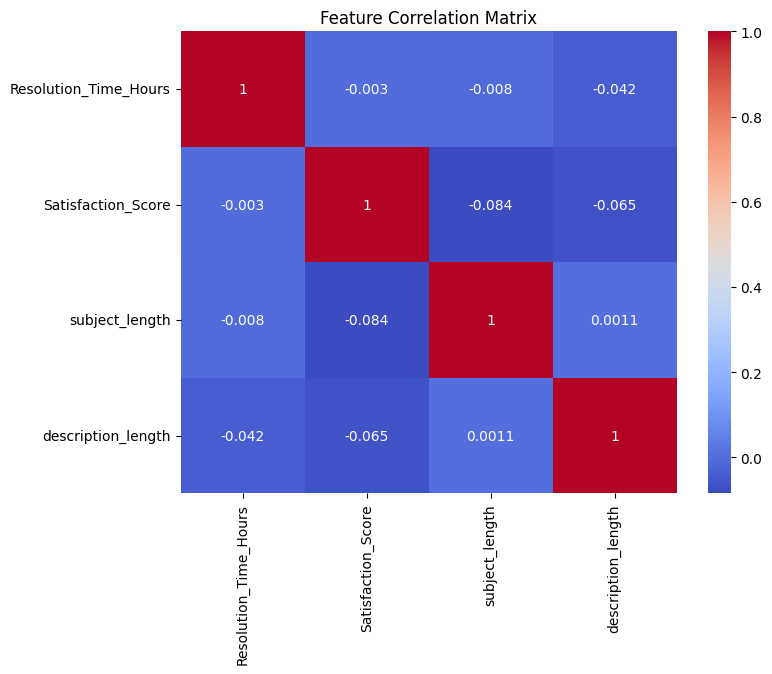

In [26]:
corr = df[
    numeric_cols
].corr()

plt.figure(
    figsize=(8,6)
)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Feature Correlation Matrix"
)

plt.show()

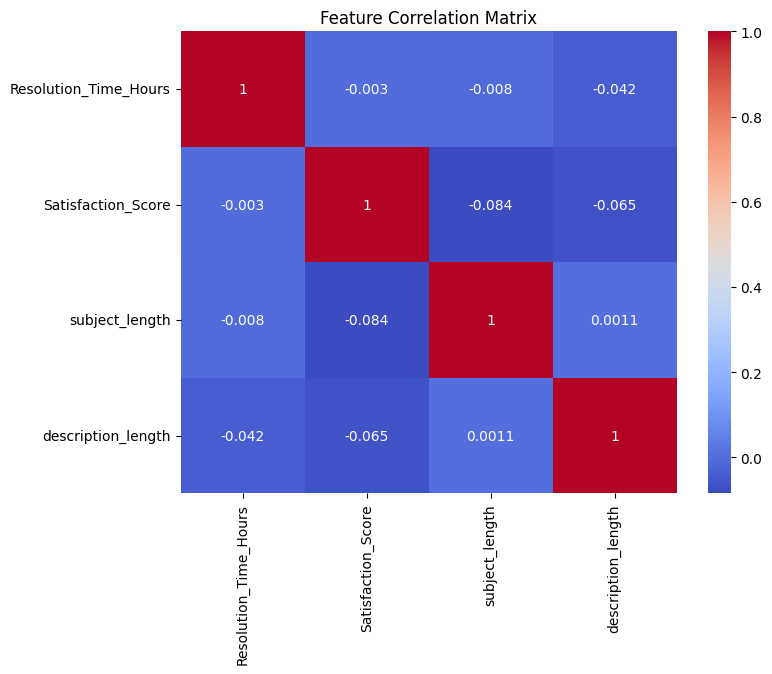

In [27]:
corr = df[
    numeric_cols
].corr()

plt.figure(
    figsize=(8,6)
)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Feature Correlation Matrix"
)

plt.show()

In [29]:
print(df["Priority_Level"].value_counts())

print(df["Resolution_Time_Hours"].describe())

print(df["Satisfaction_Score"].describe())

Priority_Level
Low         7716
Medium      7570
High        3416
Critical    1298
Name: count, dtype: int64
count    20000.000000
mean        39.230300
std         35.221884
min          1.000000
25%         11.000000
50%         27.000000
75%         58.000000
max        120.000000
Name: Resolution_Time_Hours, dtype: float64
count    20000.000000
mean         3.723700
std          1.286989
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: Satisfaction_Score, dtype: float64


In [30]:
def resolution_score(hours):

    if hours <= 11:
        return 1      # Low

    elif hours <= 27:
        return 2      # Medium

    elif hours <= 58:
        return 3      # High

    else:
        return 4      # Critical

In [31]:
def satisfaction_signal(score):

    if score == 1:
        return 4

    elif score == 2:
        return 3

    elif score == 3:
        return 2

    else:
        return 1

In [32]:
df.groupby(
    "Priority_Level"
)["Resolution_Time_Hours"].describe()

,count,mean,std,min,25%,50%,75%,max
Priority_Level,,,,,,,,
Critical,1298.0,12.068567,11.383106,1.0,4.0,9.0,16.0,80.0
High,3416.0,24.520492,23.244518,1.0,7.0,17.0,35.0,120.0
Low,7716.0,45.168351,36.649743,1.0,15.0,34.0,68.0,120.0
Medium,7570.0,44.472919,36.812959,1.0,14.0,33.0,67.0,120.0


In [33]:
df.groupby(
    "Priority_Level"
)["Satisfaction_Score"].describe()

,count,mean,std,min,25%,50%,75%,max
Priority_Level,,,,,,,,
Critical,1298.0,3.489985,1.376185,1.0,2.0,4.0,5.0,5.0
High,3416.0,3.794204,1.267724,1.0,3.0,4.0,5.0,5.0
Low,7716.0,3.692068,1.303684,1.0,3.0,4.0,5.0,5.0
Medium,7570.0,3.764201,1.257037,1.0,3.0,4.0,5.0,5.0


In [34]:
pd.crosstab(
    df["Issue_Category"],
    df["Priority_Level"]
)

Priority_Level,Critical,High,Low,Medium
Issue_Category,,,,
Account,0,405,2054,1622
Billing,0,550,2524,1962
Fraud,716,324,0,0
General Inquiry,0,389,1968,1568
Technical,582,1748,1170,2418


In [35]:
df["Submission_Date"] = pd.to_datetime(
    df["Submission_Date"]
)

In [36]:
df["month"] = (
    df["Submission_Date"]
    .dt.month
)

df["day_of_week"] = (
    df["Submission_Date"]
    .dt.dayofweek
)

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

In [38]:
df.to_csv(
    "processed_tickets.csv",
    index=False
)